# XLM-RoBERTa-base baseline

This notebook fine-tunes [`FacebookAI/xlm-roberta-base`](https://huggingface.co/FacebookAI/xlm-roberta-base) for three-class German text classification.

The model distinguishes between:

- **Human-written text**
- **AI-generated text**
- **AI-assisted text**

Training uses the prepared Hugging Face dataset created for this project, with document-level train, validation, and test splits to reduce source leakage.

The notebook includes dataset preparation, tokenization, model training, probability calibration, evaluation, error analysis, length-bias analysis, and model export.

The notebook is designed to run with GPU acceleration. Required Python packages are installed in the setup cells when running in Google Colab.

## Imports

Load the core libraries used throughout the notebook for numerical processing,
dataset handling, transformer fine-tuning, and model evaluation.

In [2]:
import numpy as np
import pandas as pd
import torch
import transformers
from pathlib import Path
from importlib.metadata import version
import json
import platform
import gc
import time
from transformers.utils import logging as transformers_logging
transformers_logging.set_verbosity_error()
from datasets import load_from_disk
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from transformers import DataCollatorWithPadding

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    EarlyStoppingCallback,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,

)

### Configuration and dataset loading

Define the main experiment settings and load the prepared three-class Hugging Face dataset from disk.

In [6]:
MODEL_NAME = "FacebookAI/xlm-roberta-base"
DATASET_PATH = "hf-dataset-3class-full"

MAX_LENGTH = 512
RANDOM_STATE = 17

dataset = load_from_disk(
    DATASET_PATH
)

dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'file', 'text', 'label', 'language', 'split', 'source', 'source_name', 'source_type', 'document_type', 'title', 'document_id', 'target_length', 'actual_word_count', 'character_count', 'original_document_length', 'publication_date', 'date_basis', 'retrieval_date', 'license_name', 'license_url', 'source_url', 'hash', 'generator_provider', 'generator_model', 'seed_sample_id'],
        num_rows: 24986
    })
    validation: Dataset({
        features: ['id', 'file', 'text', 'label', 'language', 'split', 'source', 'source_name', 'source_type', 'document_type', 'title', 'document_id', 'target_length', 'actual_word_count', 'character_count', 'original_document_length', 'publication_date', 'date_basis', 'retrieval_date', 'license_name', 'license_url', 'source_url', 'hash', 'generator_provider', 'generator_model', 'seed_sample_id'],
        num_rows: 2906
    })
    test: Dataset({
        features: ['id', 'file', 'text', 'label', 'lan

### Tokenization

Load the XLM-RoBERTa-base tokenizer, tokenize all dataset splits with a maximum sequence length of 512 tokens, and prepare dynamic padding for efficient batching.

In [7]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

columns_to_remove = [
    column
    for column in dataset["train"].column_names
    if column != "label"
]

tokenized_dataset = dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=columns_to_remove,
    desc="Tokenizing dataset",
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if torch.cuda.is_available() else None,
)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Tokenizing dataset:   0%|          | 0/24986 [00:00<?, ? examples/s]

Tokenizing dataset:   0%|          | 0/2906 [00:00<?, ? examples/s]

Tokenizing dataset:   0%|          | 0/2737 [00:00<?, ? examples/s]

### Model initialization

Load the pretrained XLM-RoBERTa-base checkpoint with a three-class classification head and determine the mixed-precision format supported by the available GPU.

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={
        0: "HUMAN",
        1: "AI",
        2: "AI_ASSISTED",
    },
    label2id={
        "HUMAN": 0,
        "AI": 1,
        "AI_ASSISTED": 2,
    },
)

use_bf16 = (
    torch.cuda.is_available()
    and torch.cuda.is_bf16_supported()
)

print("BF16:", use_bf16)

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BF16: True


### Training configuration

Define the optimization settings, evaluation strategy, mixed-precision behavior, and accuracy metric used during fine-tuning.

In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=1,
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions,
        )
    }


training_args = TrainingArguments(
    output_dir="checkpoints-xlm-roberta-base",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,
    warmup_steps=235,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    save_total_limit=2,

    bf16=use_bf16,
    fp16=torch.cuda.is_available() and not use_bf16,

    report_to="none",

    seed=RANDOM_STATE,
    data_seed=RANDOM_STATE,
)

### Trainer

Create the Hugging Face Trainer using the tokenized training and validation sets, dynamic padding, accuracy evaluation, and early stopping.

In [10]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=1
        )
    ],
)

In [11]:
train_result = trainer.train()

{'loss': '1.102', 'grad_norm': '2.423', 'learning_rate': '8.426e-06', 'epoch': '0.03201'}
{'loss': '0.9926', 'grad_norm': '26.96', 'learning_rate': '1.694e-05', 'epoch': '0.06402'}
{'loss': '0.842', 'grad_norm': '5.366', 'learning_rate': '1.986e-05', 'epoch': '0.09603'}
{'loss': '0.7403', 'grad_norm': '17.22', 'learning_rate': '1.964e-05', 'epoch': '0.128'}
{'loss': '0.5966', 'grad_norm': '74.82', 'learning_rate': '1.942e-05', 'epoch': '0.1601'}
{'loss': '0.5031', 'grad_norm': '10.5', 'learning_rate': '1.92e-05', 'epoch': '0.1921'}
{'loss': '0.5536', 'grad_norm': '20.64', 'learning_rate': '1.898e-05', 'epoch': '0.2241'}
{'loss': '0.4502', 'grad_norm': '29.35', 'learning_rate': '1.877e-05', 'epoch': '0.2561'}
{'loss': '0.4703', 'grad_norm': '6.741', 'learning_rate': '1.855e-05', 'epoch': '0.2881'}
{'loss': '0.3827', 'grad_norm': '26.62', 'learning_rate': '1.833e-05', 'epoch': '0.3201'}
{'loss': '0.3707', 'grad_norm': '53.39', 'learning_rate': '1.811e-05', 'epoch': '0.3521'}
{'loss': '0.

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.2989', 'grad_norm': '26.86', 'learning_rate': '1.351e-05', 'epoch': '1.024'}
{'loss': '0.233', 'grad_norm': '23.91', 'learning_rate': '1.329e-05', 'epoch': '1.056'}
{'loss': '0.2836', 'grad_norm': '52.42', 'learning_rate': '1.307e-05', 'epoch': '1.088'}
{'loss': '0.2823', 'grad_norm': '2.039', 'learning_rate': '1.286e-05', 'epoch': '1.12'}
{'loss': '0.2492', 'grad_norm': '107', 'learning_rate': '1.264e-05', 'epoch': '1.152'}
{'loss': '0.2339', 'grad_norm': '0.0361', 'learning_rate': '1.242e-05', 'epoch': '1.184'}
{'loss': '0.2993', 'grad_norm': '71.96', 'learning_rate': '1.22e-05', 'epoch': '1.216'}
{'loss': '0.2852', 'grad_norm': '0.2985', 'learning_rate': '1.198e-05', 'epoch': '1.248'}
{'loss': '0.2681', 'grad_norm': '64.42', 'learning_rate': '1.176e-05', 'epoch': '1.28'}
{'loss': '0.2698', 'grad_norm': '2.728', 'learning_rate': '1.154e-05', 'epoch': '1.312'}
{'loss': '0.2391', 'grad_norm': '0.08316', 'learning_rate': '1.132e-05', 'epoch': '1.344'}
{'loss': '0.1804', 'gra

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1937', 'grad_norm': '2.013', 'learning_rate': '6.726e-06', 'epoch': '2.017'}
{'loss': '0.1162', 'grad_norm': '0.1236', 'learning_rate': '6.508e-06', 'epoch': '2.049'}
{'loss': '0.17', 'grad_norm': '0.07565', 'learning_rate': '6.289e-06', 'epoch': '2.081'}
{'loss': '0.1759', 'grad_norm': '83.6', 'learning_rate': '6.07e-06', 'epoch': '2.113'}
{'loss': '0.196', 'grad_norm': '0.4318', 'learning_rate': '5.851e-06', 'epoch': '2.145'}
{'loss': '0.1197', 'grad_norm': '0.1084', 'learning_rate': '5.632e-06', 'epoch': '2.177'}
{'loss': '0.1443', 'grad_norm': '62.78', 'learning_rate': '5.413e-06', 'epoch': '2.209'}
{'loss': '0.2154', 'grad_norm': '0.2239', 'learning_rate': '5.194e-06', 'epoch': '2.241'}
{'loss': '0.1045', 'grad_norm': '145.8', 'learning_rate': '4.975e-06', 'epoch': '2.273'}
{'loss': '0.1525', 'grad_norm': '0.0134', 'learning_rate': '4.756e-06', 'epoch': '2.305'}
{'loss': '0.1806', 'grad_norm': '0.03998', 'learning_rate': '4.538e-06', 'epoch': '2.337'}
{'loss': '0.1494'

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '589', 'train_samples_per_second': '127.3', 'train_steps_per_second': '15.91', 'train_loss': '0.2838', 'epoch': '3'}


### Probability calibration

Use the validation split to learn a temperature-scaling parameter for XLM-RoBERTa-base. Temperature scaling adjusts the confidence of the model's predicted probabilities without changing the predicted class labels.

In [12]:
validation_output = trainer.predict(
    tokenized_dataset["validation"]
)

validation_logits = np.asarray(
    validation_output.predictions
)

y_validation = np.asarray(
    dataset["validation"]["label"],
    dtype=np.int64,
)


def fit_temperature(logits, labels):

    logits_tensor = torch.tensor(
        logits,
        dtype=torch.float64,
    )

    labels_tensor = torch.tensor(
        labels,
        dtype=torch.long,
    )

    log_temperature = torch.nn.Parameter(
        torch.zeros(
            (),
            dtype=torch.float64,
        )
    )

    criterion = torch.nn.CrossEntropyLoss()

    optimizer = torch.optim.LBFGS(
        [log_temperature],
        lr=0.1,
        max_iter=50,
        line_search_fn="strong_wolfe",
    )

    def closure():
        optimizer.zero_grad()

        temperature = log_temperature.exp()

        loss = criterion(
            logits_tensor / temperature,
            labels_tensor,
        )

        loss.backward()

        return loss

    optimizer.step(closure)

    return float(
        log_temperature.exp().detach()
    )


def probabilities_from_logits(
    logits,
    temperature=1.0,
):

    scaled_logits = (
        np.asarray(
            logits,
            dtype=np.float64,
        )
        / temperature
    )

    scaled_logits -= scaled_logits.max(
        axis=1,
        keepdims=True,
    )

    exponentiated = np.exp(
        scaled_logits
    )

    return (
        exponentiated
        / exponentiated.sum(
            axis=1,
            keepdims=True,
        )
    )


XLM_ROBERTA_TEMPERATURE = fit_temperature(
    validation_logits,
    y_validation,
)

print(
    f"Learned XLM-RoBERTa-base temperature: "
    f"{XLM_ROBERTA_TEMPERATURE:.4f}"
)

Learned XLM-RoBERTa-base temperature: 2.5073


### Calibration evaluation

Compare XLM-RoBERTa-base's probability quality before and after temperature scaling. The Brier score and log loss measure how well the predicted probabilities match the true class labels, with lower values indicating better calibration.

In [13]:
from sklearn.metrics import log_loss
import numpy as np
import pandas as pd


def multiclass_brier_score(y_true, probabilities, n_classes=3):

    y_onehot = np.eye(n_classes)[y_true]

    return np.mean(
        np.sum(
            (probabilities - y_onehot) ** 2,
            axis=1,
        )
    )


uncalibrated_validation_probabilities = probabilities_from_logits(
    validation_logits
)

calibrated_validation_probabilities = probabilities_from_logits(
    validation_logits,
    XLM_ROBERTA_TEMPERATURE,
)


calibration_comparison = pd.DataFrame(
    [
        {
            "model": "Uncalibrated",

            "Brier score": multiclass_brier_score(
                y_validation,
                uncalibrated_validation_probabilities,
            ),

            "Log loss": log_loss(
                y_validation,
                uncalibrated_validation_probabilities,
                labels=[0, 1, 2],
            ),
        },

        {
            "model": "Temperature-scaled",

            "Brier score": multiclass_brier_score(
                y_validation,
                calibrated_validation_probabilities,
            ),

            "Log loss": log_loss(
                y_validation,
                calibrated_validation_probabilities,
                labels=[0, 1, 2],
            ),
        },
    ]
).set_index("model")


calibration_comparison.style.format(
    "{:.4f}"
)

,Brier score,Log loss
model,,
Uncalibrated,0.1579,0.4885
Temperature-scaled,0.1366,0.2619


### Final split evaluation

Evaluate the calibrated XLM-RoBERTa-base model on the training, validation, and test splits using accuracy, multiclass Brier score, log loss, and confusion matrices.

In [14]:
split_logits = {
    "validation": validation_logits
}

for split_name in ("train", "test"):
    prediction_output = trainer.predict(
        tokenized_dataset[split_name]
    )

    split_logits[split_name] = np.asarray(
        prediction_output.predictions
    )


def evaluate_split(split_name):
    y_true = np.asarray(
        dataset[split_name]["label"],
        dtype=np.int64,
    )

    probabilities = probabilities_from_logits(
        split_logits[split_name],
        XLM_ROBERTA_TEMPERATURE,
    )

    y_pred = np.argmax(
        probabilities,
        axis=1,
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1, 2],
    )

    return {
        "split": split_name,

        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),

        "brier_score": multiclass_brier_score(
            y_true,
            probabilities,
        ),

        "log_loss": log_loss(
            y_true,
            probabilities,
            labels=[0, 1, 2],
        ),

        "confusion_matrix": cm,
    }


evaluation = pd.DataFrame(
    [
        evaluate_split("train"),
        evaluate_split("validation"),
        evaluate_split("test"),
    ]
).set_index("split")


evaluation.style.format(
    {
        "accuracy": "{:.2%}",
        "brier_score": "{:.4f}",
        "log_loss": "{:.4f}",
    }
)

,accuracy,brier_score,log_loss,confusion_matrix
split,,,,
train,95.37%,0.0758,0.1610,[[7281 6 1055] [ 3 8299 22] [ 35 37 8248]]
validation,91.74%,0.1366,0.2619,[[779 2 190] [ 2 956 9] [ 19 18 931]]
test,91.09%,0.1476,0.2793,[[716 2 196] [ 0 904 8] [ 17 21 873]]


### Test-set confusion matrix

Visualize the three-class confusion matrix for XLM-RoBERTa-base on the test split to inspect which classes are predicted correctly and where misclassifications occur.

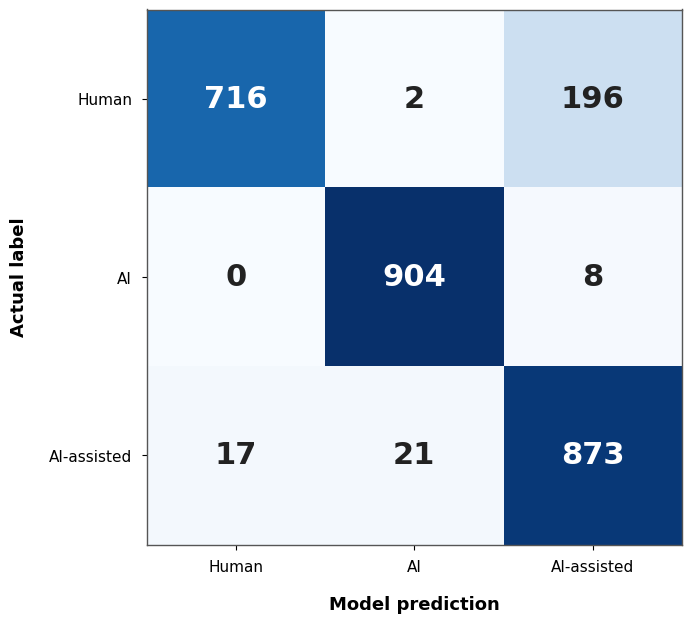

In [15]:
y_test = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

test_probabilities = probabilities_from_logits(
    split_logits["test"],
    XLM_ROBERTA_TEMPERATURE,
)

y_test_pred = np.argmax(
    test_probabilities,
    axis=1,
)

test_matrix = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1, 2],
)

class_names = [
    "Human",
    "AI",
    "AI-assisted",
]

fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(
    test_matrix,
    cmap="Blues",
    vmin=0,
    vmax=test_matrix.max(),
)

for row in range(3):
    for column in range(3):

        value = test_matrix[row, column]

        text_color = (
            "white"
            if value > test_matrix.max() / 2
            else "#222222"
        )

        ax.text(
            column,
            row,
            f"{value:,}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=22,
            fontweight="bold",
        )

ax.set_xticks(
    [0, 1, 2],
    labels=class_names,
)

ax.set_yticks(
    [0, 1, 2],
    labels=class_names,
)

ax.set_xlabel(
    "Model prediction",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.set_ylabel(
    "Actual label",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.tick_params(
    axis="both",
    labelsize=11,
    pad=7,
)

for spine in ax.spines.values():
    spine.set_color("#555555")
    spine.set_linewidth(1)

fig.tight_layout()

plt.savefig(
    "xlm-roberta-base-confmat-3class.svg"
)

plt.show()

### Binary Human-vs-AI confusion matrix

Evaluate XLM-RoBERTa-base only on Human and fully AI-generated test samples. AI-assisted samples are excluded, and the remaining Human and AI probabilities are renormalized before applying a binary decision threshold.

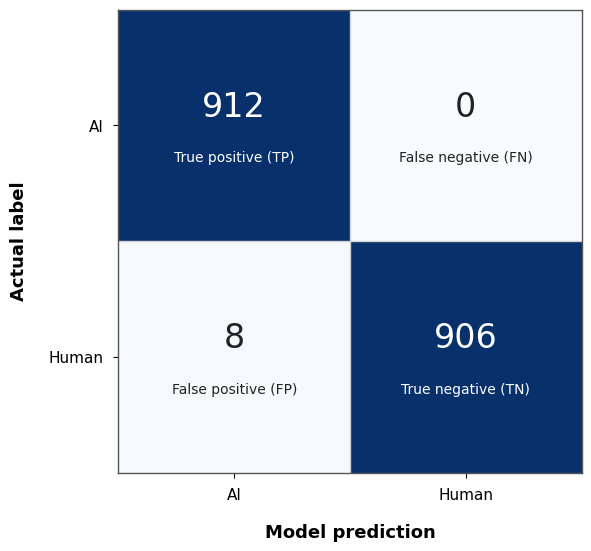

In [16]:
y_test_all = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

mask = y_test_all != 2

y_test = y_test_all[mask]

test_logits_binary = split_logits["test"][mask]

test_probabilities = probabilities_from_logits(
    test_logits_binary,
    XLM_ROBERTA_TEMPERATURE,
)

human_prob = test_probabilities[:, 0]
ai_prob = test_probabilities[:, 1]

total = human_prob + ai_prob

human_prob = human_prob / total
ai_prob = ai_prob / total

y_test_pred = (
    ai_prob >= 0.5
).astype(np.int64)

test_matrix = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[1, 0],
)

cell_labels = np.asarray(
    [
        ["True positive (TP)", "False negative (FN)"],
        ["False positive (FP)", "True negative (TN)"],
    ]
)

fig, ax = plt.subplots(
    figsize=(6, 6)
)

ax.imshow(
    test_matrix,
    cmap="Blues",
    vmin=0,
    vmax=test_matrix.max(),
)

for row in range(2):
    for column in range(2):

        value = test_matrix[
            row,
            column
        ]

        text_color = (
            "white"
            if value > test_matrix.max() / 2
            else "#222222"
        )

        ax.text(
            column,
            row - 0.08,
            f"{value:,}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=24,
        )

        ax.text(
            column,
            row + 0.14,
            cell_labels[row, column],
            ha="center",
            va="center",
            color=text_color,
            fontsize=10,
        )

ax.set_xticks(
    [0, 1],
    labels=["AI", "Human"],
)

ax.set_yticks(
    [0, 1],
    labels=["AI", "Human"],
)

ax.set_xlabel(
    "Model prediction",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.set_ylabel(
    "Actual label",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.axhline(
    0.5,
    color="#d0d0d0",
    linewidth=1,
)

ax.axvline(
    0.5,
    color="#d0d0d0",
    linewidth=1,
)

ax.tick_params(
    axis="both",
    labelsize=11,
    pad=7,
)

for spine in ax.spines.values():
    spine.set_color("#555555")
    spine.set_linewidth(1)

fig.tight_layout()

plt.savefig(
    "xlm-roberta-base-confmat-human-ai.svg"
)

plt.show()

### Error analysis

Inspect XLM-RoBERTa-base's highest-confidence misclassifications on the test set, including the true label, predicted class, calibrated class probabilities, source information, generator metadata, and a short text preview.

In [17]:
label_names = {
    0: "Human",
    1: "AI",
    2: "AI-assisted",
}

y_test = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

test_probabilities = probabilities_from_logits(
    split_logits["test"],
    XLM_ROBERTA_TEMPERATURE,
)

y_test_pred = np.argmax(
    test_probabilities,
    axis=1,
)

prediction_confidence = np.max(
    test_probabilities,
    axis=1,
)

test_errors = pd.DataFrame(
    {
        "id": dataset["test"]["id"],
        "actual": [
            label_names[label]
            for label in y_test
        ],
        "prediction": [
            label_names[label]
            for label in y_test_pred
        ],
        "prediction_confidence": prediction_confidence,
        "human_probability": test_probabilities[:, 0],
        "ai_probability": test_probabilities[:, 1],
        "ai_assisted_probability": test_probabilities[:, 2],
        "source_name": dataset["test"]["source_name"],
        "generator_model": dataset["test"]["generator_model"],
        "text": [
            text[:300]
            for text in dataset["test"]["text"]
        ],
    }
)

test_errors = test_errors[
    test_errors["actual"]
    != test_errors["prediction"]
].copy()

test_errors.sort_values(
    "prediction_confidence",
    ascending=False,
).head(20).style.format(
    {
        "prediction_confidence": "{:.2%}",
        "human_probability": "{:.2%}",
        "ai_probability": "{:.2%}",
        "ai_assisted_probability": "{:.2%}",
    }
)

,id,actual,prediction,prediction_confidence,human_probability,ai_probability,ai_assisted_probability,source_name,generator_model,text
774,8594,Human,AI,96.35%,1.55%,96.35%,2.10%,SSOAR,None,"Drittens erfolgen Risikoallokationen in PPP-Vorhaben weniger durch Wettbewerbsprozesse unter Nutzung dezentraler Marktmechanismen, sondern beruhen vornehmlich auf subjektiven Expertenschätzungen, deren Urteile mehr den persönlichen Informationsstand denn stochastisch abgesicherte Bewertungen widersp"
2192,24770,AI-assisted,AI,95.88%,1.49%,95.88%,2.63%,Refubium (FU Berlin),gemini,"Berlins exzellente Forschung wird künftig noch sichtbarer, häufiger zitiert und weiter verbreitet werden. Die digitale Veröffentlichung von Wissen stärkt nachhaltig das Profil der Berliner Wissenschaftslandschaft und schafft zugleich einen fruchtbaren Nährboden für Start-ups und Kreative. Indem der"
222,2705,Human,AI-assisted,95.51%,2.65%,1.84%,95.51%,SSOAR,None,"Demnach lässt sich die Relevanz der zur Verfügung stehenden materiellen Ressourcen (Materialität der Dinge) erklären, wie beispielsweise einer technischen Infrastruktur. Die Bedeutsamkeit der kompetenten Körper (vgl. Schmidt 2012, S. 56) sowie das Geflecht aus mehr oder minder formalisierten Netzwer"
119,1384,Human,AI-assisted,95.46%,2.79%,1.75%,95.46%,SSOAR,None,"Diese Diskussionen aufgreifend, wird Internationale Politische Theorie (IPT) im Folgenden als ein Forschungsfeld verstanden, das an beide Teildisziplinen anschließt und das zugleich in deren Zusammenführung über sie hinausgeht und neue Perspektiven ermöglicht. So verstanden ist Internationale Politi"
2597,29008,AI-assisted,AI,95.45%,1.49%,95.45%,3.06%,SSOAR,gpt-6-luna,"Drittens werden Risiken in PPP-Vorhaben weniger über Wettbewerbsprozesse und dezentrale Marktmechanismen verteilt, sondern vorwiegend anhand subjektiver Expertenschätzungen bewertet. Deren Urteile spiegeln eher den persönlichen Informationsstand als stochastisch abgesicherte Einschätzungen wider. Da"
2508,28323,AI-assisted,AI,95.37%,1.57%,95.37%,3.06%,peDOCS (DIPF),gpt-6-luna,"Die Einteilung in Phasen bietet für die praktische Zeitplanung eines Veränderungsprozesses keinen eigenständigen Erklärungswert. Auch neuere Modelle, die berücksichtigen, dass sich einzelne Phasen überschneiden und verschiedene Stränge des Veränderungsprozesses zeitlich eng miteinander verflochten s"
117,1347,Human,AI-assisted,95.24%,3.02%,1.74%,95.24%,SSOAR,None,"Dessen relative Geringschätzung auch durch die Schulbehörden und Schulleitungen drückt sich unter anderem darin aus, dass zur Behebung des Lehrermangels an beruflichen Schulen immer wieder Absolventen technologischer Studiengänge als Lehrkräfte eingestellt und häufig schon nach kurzer Zeit ohne ange"
156,1824,Human,AI-assisted,95.19%,3.09%,1.72%,95.19%,SSOAR,None,"Initiiert wurde das Netzwerk, weil die Bezugnahme auf und die Rekonstruktion von wirtschaftswissenschaftlichem Wissen von der deutschsprachigen Soziologie – verglichen mit der englischsprachigen Debatte – noch relativ wenig erforscht wurde. Ziel des Zusammenschlusses ist es daher, die Entwicklung ei"
415,4628,Human,AI-assisted,95.18%,3.25%,1.58%,95.18%,Refubium (FU Berlin),None,Dementsprechend wurden auf hochschulpolitischer Ebene Ziele definiert. So zählt im Positionspapier „Leistung aus Vielfalt“ des Rates für Informationsinfrastrukturen „Informations- und Datenmanagementkompetenz in der Breite und auf allen Ebenen vermitteln“ zu den Empfehlungen mit höchster Priorität.
726,8265,Human,AI-assisted,95.15%,2.76%,2.09%,95.15%,SSOAR,None,"Als globales Ergebnis bleibt festzuhalten, dass die Milieustruktur der Älteren von jener der Gesamtbevölkerung signifikant abweicht. Verschiedene Lebenswelten wie das konservative gehobene Milieu, das kleinbürgerliche Milieu sowie das traditionelle Arbeitermilieu sind weit überproportional vertreten"


### Model export

Save the fine-tuned XLM-RoBERTa-base model and tokenizer together with the calibration parameter, label mapping, validation performance, training configuration, and software versions required to reproduce inference.

In [18]:
ARTIFACT_DIR = Path("artifacts") / "xlm-roberta-base-3class"

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

trainer.save_model(
    ARTIFACT_DIR
)

tokenizer.save_pretrained(
    ARTIFACT_DIR
)

validation_predictions = np.argmax(
    validation_logits,
    axis=1,
)

best_validation_accuracy = accuracy_score(
    y_validation,
    validation_predictions,
)

metadata = {
    "dataset": DATASET_PATH,
    "base_model": MODEL_NAME,
    "label_mapping": {
        "human": 0,
        "ai": 1,
        "ai_assisted": 2,
    },
    "max_length": MAX_LENGTH,
    "calibration": "temperature scaling",
    "temperature": float(
        XLM_ROBERTA_TEMPERATURE
    ),
    "best_validation_accuracy": float(
        best_validation_accuracy
    ),
    "best_checkpoint": (
        trainer.state.best_model_checkpoint
    ),
    "random_state": RANDOM_STATE,
    "python_version": platform.python_version(),
    "package_versions": {
        package: version(package)
        for package in [
            "datasets",
            "numpy",
            "scikit-learn",
            "torch",
            "transformers",
        ]
    },
}

METADATA_PATH = (
    ARTIFACT_DIR
    / "detector-config.json"
)

METADATA_PATH.write_text(
    json.dumps(
        metadata,
        indent=2,
    ) + "\n",
    encoding="utf-8",
)

print(
    f"Saved model and tokenizer to: "
    f"{ARTIFACT_DIR}"
)

print(
    f"Saved detector configuration to: "
    f"{METADATA_PATH}"
)

print(
    f"Validation accuracy: "
    f"{best_validation_accuracy:.2%}"
)

print(
    f"Temperature: "
    f"{XLM_ROBERTA_TEMPERATURE:.4f}"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model and tokenizer to: artifacts/xlm-roberta-base-3class
Saved detector configuration to: artifacts/xlm-roberta-base-3class/detector-config.json
Validation accuracy: 91.74%
Temperature: 2.5073


### Reload and test the exported model

Reload the saved XLM-RoBERTa-base model, tokenizer, and detector configuration from the artifact directory, move the model to the available inference device, and run a sample prediction using the stored temperature-scaling parameter.

In [19]:
ARTIFACT_DIR = Path("artifacts") / "xlm-roberta-base-3class"

METADATA_PATH = (
    ARTIFACT_DIR
    / "detector-config.json"
)

loaded_tokenizer = AutoTokenizer.from_pretrained(
    ARTIFACT_DIR
)

loaded_model = AutoModelForSequenceClassification.from_pretrained(
    ARTIFACT_DIR
)

loaded_config = json.loads(
    METADATA_PATH.read_text(
        encoding="utf-8"
    )
)

if torch.cuda.is_available():
    inference_device = torch.device("cuda")

elif (
    hasattr(torch.backends, "mps")
    and torch.backends.mps.is_available()
):
    inference_device = torch.device("mps")

else:
    inference_device = torch.device("cpu")

print("Device:", inference_device)

loaded_model.to(
    inference_device
)

loaded_model.eval()


def predict_probabilities(texts):
    inputs = loaded_tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=loaded_config["max_length"],
        return_tensors="pt",
    )

    inputs = {
        key: value.to(inference_device)
        for key, value in inputs.items()
    }

    with torch.inference_mode():
        logits = loaded_model(
            **inputs
        ).logits

        calibrated_logits = (
            logits
            / loaded_config["temperature"]
        )

        probabilities = torch.softmax(
            calibrated_logits,
            dim=1,
        )

    return probabilities.cpu().numpy()


id2label = {
    0: "Human",
    1: "AI",
    2: "AI-assisted",
}

texts = [
    """
    Die fortschreitende Digitalisierung von Entscheidungsprozessen in Verwaltung und Politik wird häufig als neutraler Rationalisierungsschritt dargestellt. Diese Sichtweise verkennt jedoch den normativen Charakter technologischer Systeme. Algorithmen und datengestützte Modelle sind keine objektiv reflektierenden Instrumente; sie begründen sich stets auf spezifischen Prämissen, Datenselektionen und Zielvorgaben ihrer Entwickler. Wenn komplexe gesellschaftliche Zielkonflikte rein technokratisch behandelt werden, droht eine Entpolitisierung essenzieller Debatten. Technische Systeme können zwar Effizienz steigern und Informationsgrundlagen strukturieren, sie ersetzen jedoch weder die ethische Folgenabschätzung noch die demokratische Legitimation. Eine nachhaltige gesellschaftliche Transformation erfordert daher, die Systemarchitekturen kontinuierlich an rechtsstaatlichen Werten und sozialer Verantwortung zu messen, anstatt politische Ermessensspielräume an automatisierte Prozesse abzutreten.
    """
]

probabilities = predict_probabilities(
    texts
)

for text, probs in zip(
    texts,
    probabilities,
):
    prediction = int(
        np.argmax(probs)
    )

    label = id2label[
        prediction
    ]

    print(
        f"Prediction: {label}"
    )

    print(
        f"Human:       {probs[0]:.1%}"
    )

    print(
        f"AI:          {probs[1]:.1%}"
    )

    print(
        f"AI-assisted: {probs[2]:.1%}"
    )

    print(
        f"\n{text}"
    )

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Device: cuda
Prediction: AI
Human:       1.6%
AI:          96.5%
AI-assisted: 1.9%


    Die fortschreitende Digitalisierung von Entscheidungsprozessen in Verwaltung und Politik wird häufig als neutraler Rationalisierungsschritt dargestellt. Diese Sichtweise verkennt jedoch den normativen Charakter technologischer Systeme. Algorithmen und datengestützte Modelle sind keine objektiv reflektierenden Instrumente; sie begründen sich stets auf spezifischen Prämissen, Datenselektionen und Zielvorgaben ihrer Entwickler. Wenn komplexe gesellschaftliche Zielkonflikte rein technokratisch behandelt werden, droht eine Entpolitisierung essenzieller Debatten. Technische Systeme können zwar Effizienz steigern und Informationsgrundlagen strukturieren, sie ersetzen jedoch weder die ethische Folgenabschätzung noch die demokratische Legitimation. Eine nachhaltige gesellschaftliche Transformation erfordert daher, die Systemarchitekturen kontinuierlich an rechtsstaatlichen Werten und sozialer Verantwortung 

### Length-bias analysis

Evaluate XLM-RoBERTa-base performance across different text-length ranges to check whether classification quality changes for shorter or longer samples. For each length bin, report class counts, accuracy, mean class confidence, and class-specific error rates.

In [20]:
y_test = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

texts = np.asarray(
    dataset["test"]["text"],
    dtype=object,
)

test_logits = split_logits["test"]

test_probabilities = probabilities_from_logits(
    test_logits,
    XLM_ROBERTA_TEMPERATURE,
)

y_test_pred = np.argmax(
    test_probabilities,
    axis=1,
)

word_lengths = np.asarray([
    len(text.split())
    for text in texts
])

length_bins = [
    (0, 70, "≤70"),
    (71, 150, "71–150"),
    (151, 300, "151–300"),
    (301, 500, "301–500"),
    (501, 750, "501–750"),
    (751, np.inf, "750+"),
]

rows = []

for lower, upper, name in length_bins:
    bin_mask = (
        (word_lengths >= lower)
        & (word_lengths <= upper)
    )

    y_bin = y_test[bin_mask]
    pred_bin = y_test_pred[bin_mask]
    probabilities_bin = test_probabilities[
        bin_mask
    ]

    if len(y_bin) == 0:
        continue

    human_mask = y_bin == 0
    ai_mask = y_bin == 1
    ai_assisted_mask = y_bin == 2

    mean_human_score = (
        probabilities_bin[
            human_mask,
            0
        ].mean() * 100
    )

    mean_ai_score = (
        probabilities_bin[
            ai_mask,
            1
        ].mean() * 100
    )

    mean_ai_assisted_score = (
        probabilities_bin[
            ai_assisted_mask,
            2
        ].mean() * 100
    )

    human_error_rate = np.mean(
        pred_bin[human_mask] != 0
    )

    ai_error_rate = np.mean(
        pred_bin[ai_mask] != 1
    )

    ai_assisted_error_rate = np.mean(
        pred_bin[ai_assisted_mask] != 2
    )

    rows.append(
        {
            "model": "XLM-RoBERTa-base",
            "length_bin": name,
            "samples": len(y_bin),
            "human_samples": human_mask.sum(),
            "ai_samples": ai_mask.sum(),
            "ai_assisted_samples": ai_assisted_mask.sum(),
            "accuracy": accuracy_score(
                y_bin,
                pred_bin,
            ),
            "mean_human_score": mean_human_score,
            "mean_ai_score": mean_ai_score,
            "mean_ai_assisted_score": mean_ai_assisted_score,
            "human_error_rate": human_error_rate,
            "ai_error_rate": ai_error_rate,
            "ai_assisted_error_rate": ai_assisted_error_rate,
        }
    )

xlm_roberta_length_results_3class = pd.DataFrame(
    rows
)

xlm_roberta_length_results_3class

,model,length_bin,samples,human_samples,ai_samples,ai_assisted_samples,accuracy,mean_human_score,mean_ai_score,mean_ai_assisted_score,human_error_rate,ai_error_rate,ai_assisted_error_rate
0,XLM-RoBERTa-base,≤70,399,134,134,131,0.829574,65.065130,90.521124,79.249159,0.320896,0.052239,0.137405
1,XLM-RoBERTa-base,71–150,293,94,122,77,0.911263,72.808412,95.610197,90.341915,0.234043,0.008197,0.038961
2,XLM-RoBERTa-base,151–300,640,207,245,188,0.917188,73.037342,96.423919,92.316499,0.231884,0.000000,0.026596
3,XLM-RoBERTa-base,301–500,342,106,89,147,0.944444,79.487410,96.463355,93.149588,0.150943,0.000000,0.020408
4,XLM-RoBERTa-base,501–750,653,233,191,229,0.935681,80.089503,96.405398,92.803116,0.154506,0.000000,0.026201
5,XLM-RoBERTa-base,750+,410,140,131,139,0.912195,72.527791,96.469242,93.305360,0.235714,0.000000,0.021583
